# LiteALPR Demo
Welcome to the official demo for **LiteALPR**, an extremely fast and accurate License Plate Recognition system built on YOLOv8n-Efficient and SVTR26-Tiny. This notebook is designed to help you get started quickly.

In [1]:
# Install the necessary libraries
!pip install litealpr[gpu] huggingface_hub opencv-python matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.9 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 484.3/484.3 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 29.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 78.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.7/246.7 MB 7.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 976.9/976.9 kB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.7/54.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 71.8 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstal

In [ ]:
# Restart session
import os

os._exit(0)

## 1. Import and Initialize
The `LiteALPR` class will automatically download the pre-trained weights (`YOLOv8n-Efficient` and `SVTR26-Tiny`) from Hugging Face if you don't provide local paths.

In [1]:
import cv2
import matplotlib.pyplot as plt

from litealpr import LiteALPR

# Initialize the End-to-End Pipeline
model = LiteALPR(device='cuda:0') # Use 'cpu' if you want to use CPU

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
[LiteALPR] Initializing on cuda:0...
[LiteALPR] Downloading/Verifying yolov8n_efficient/best_416.onnx from HuggingFace...


yolov8n_efficient/best_416.onnx:   0%|          | 0.00/8.15M [00:00<?, ?B/s]

[LiteALPR] Loading Detection Model: /root/.cache/huggingface/hub/models--anhone3--LiteALPR/snapshots/efddb217184a7b0de9e5ca5f17072221e3bc6c6d/yolov8n_efficient/best_416.onnx
[LiteALPR] Downloading/Verifying svtr26_tiny/best.onnx from HuggingFace...


svtr26_tiny/best.onnx:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

[LiteALPR] Loading Recognition Model: /root/.cache/huggingface/hub/models--anhone3--LiteALPR/snapshots/efddb217184a7b0de9e5ca5f17072221e3bc6c6d/svtr26_tiny/best.onnx
[LiteALPR] Models loaded successfully!


## 2. Download Sample Image

In [2]:
import urllib.request

image_url = 'https://raw.githubusercontent.com/vn-anhnth/LiteALPR/main/dataset/det/test/images/carlong_0178.png'
urllib.request.urlretrieve(image_url, 'sample.jpg')

('sample.jpg', <http.client.HTTPMessage at 0x79f706324470>)

## 3. Run Inference

In [3]:
results = model.read('sample.jpg')
print("Detected License Plates:")
for res in results:
    print(f"Text: {res['text']} | Confidence: {res['score']:.2f} | BBox: {res['box']}")

Loading /root/.cache/huggingface/hub/models--anhone3--LiteALPR/snapshots/efddb217184a7b0de9e5ca5f17072221e3bc6c6d/yolov8n_efficient/best_416.onnx for ONNX Runtime inference...
WARNING ⚠️ Failed to start ONNX Runtime with CUDA. Using CPU...
Using ONNX Runtime CPUExecutionProvider
Detected License Plates:
Text: 51G51332 | Confidence: 1.00 | BBox: [167, 229, 271, 262]


## 4. Visualize Results

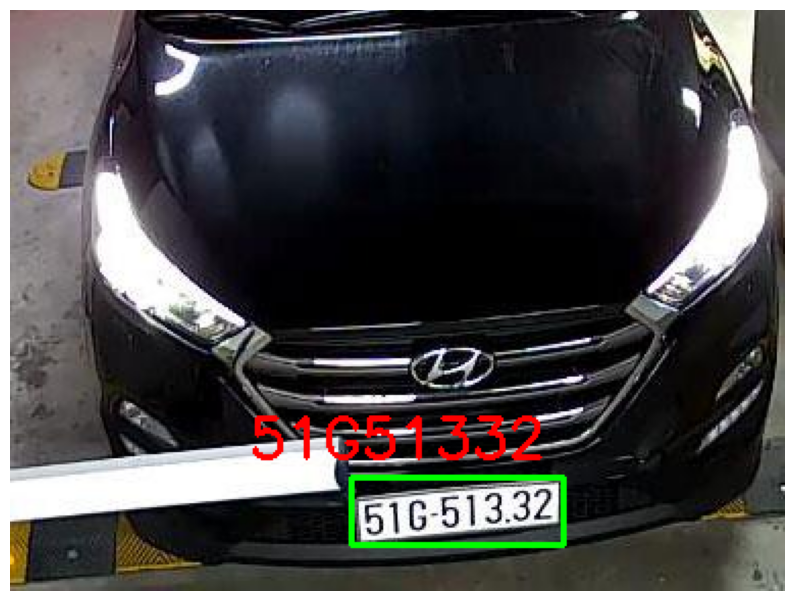

In [4]:
img = cv2.imread('sample.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

for res in results:
    x1, y1, x2, y2 = res['box']
    text = res['text']

    # Draw BBox
    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)
    # Draw Text
    cv2.putText(img, text, (x1 - 50, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)

plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis('off')
plt.show()